# EDA Second Batch

In [52]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Import 2, 3, 4, 5, 6 sheet from the excel file
# Define the path to the Excel file
excel_file = os.path.join('..', 'data', 'Bloomberg_second_batch.xlsx')

# List of sheet indices to import (2nd to 6th sheet: indices 1 to 5)
sheet_indices = list(range(0, 8))

# Read the sheets into a list of DataFrames
sheets = pd.read_excel(excel_file, sheet_name=sheet_indices)

bonds_df = sheets[2]
price_df = sheets[5]
bid_df = sheets[6]
ask_df = sheets[7]

## Bonds V2 Sheet

In [53]:
bonds_df.head()

,Issuer Name,Ticker,Issue Date,Mid Price,Mac Dur (Ask),Ask Price,Bid Price,CUSIP,Pricing Date,Liquidity Score (LQA),...,Currency,CPN_FREQ,RTG_MOODY,BICS_LEVEL_1_SECTOR_NAME,BICS_LEVEL_2_INDUSTRY_GROUP_NAME,DUR_ADJ_MID,Exclude_1,Exclude_2,Exclude_3,Exclude_4
0,Abu Dhabi Commercial Bank PJSC,ADCBUH,9/12/2023,102.6720,2.640158,102.796,102.548,ZI6396645,9/5/2023,54,...,USD,2,NaN,Financials,Banks,2.582170,0,0,0,0
1,Abu Dhabi Commercial Bank PJSC,ADCBUH,7/18/2023,101.8680,2.221264,101.949,101.787,ZJ7425375,7/11/2023,55,...,USD,2,NaN,Financials,Banks,2.172039,0,0,0,0
2,Abu Dhabi Crude Oil Pipeline LLC,ADNOUH,11/2/2017,97.2900,3.412174,97.405,97.175,00401MAA4,10/26/2017,53,...,USD,2,NaN,Energy,Pipeline,3.337516,0,0,0,0
3,Abu Dhabi National Energy Co PJSC,TAQAUH,10/9/2024,98.4855,4.910503,98.579,98.392,00388WAQ4,10/2/2024,57,...,USD,2,Aa3,Utilities,Power Generation,4.797735,0,0,0,0
4,African Development Bank,AFDB,3/14/2023,101.3005,1.901773,101.313,101.288,00828EER6,3/7/2023,95,...,USD,2,Aaa,Government,Supranationals,1.867237,0,0,0,0


In [54]:
print(bonds_df.info())
print("="*100)
print(bonds_df.describe().T)
print("="*100)
print(bonds_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Issuer Name                       281 non-null    object 
 1   Ticker                            281 non-null    object 
 2   Issue Date                        281 non-null    object 
 3   Mid Price                         281 non-null    float64
 4   Mac Dur (Ask)                     281 non-null    float64
 5   Ask Price                         281 non-null    float64
 6   Bid Price                         281 non-null    float64
 7   CUSIP                             281 non-null    object 
 8   Pricing Date                      281 non-null    object 
 9   Liquidity Score (LQA)             281 non-null    int64  
 10  Amt Out                           281 non-null    int64  
 11  Cpn                               281 non-null    float64
 12  Maturity

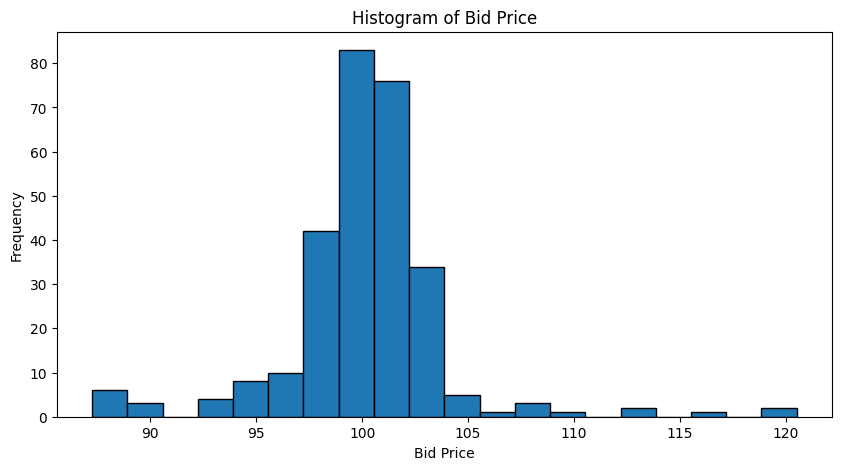

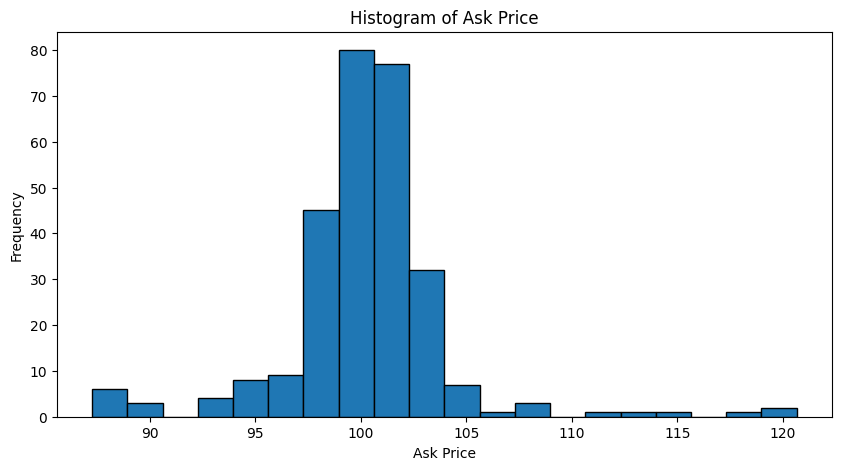

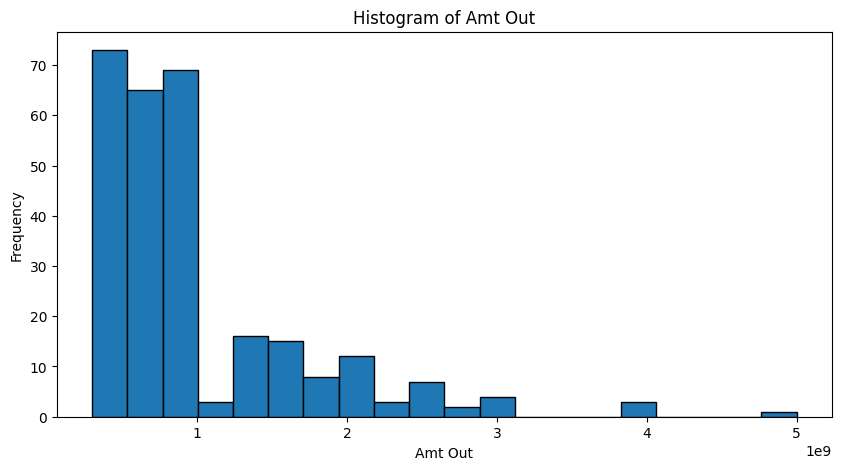

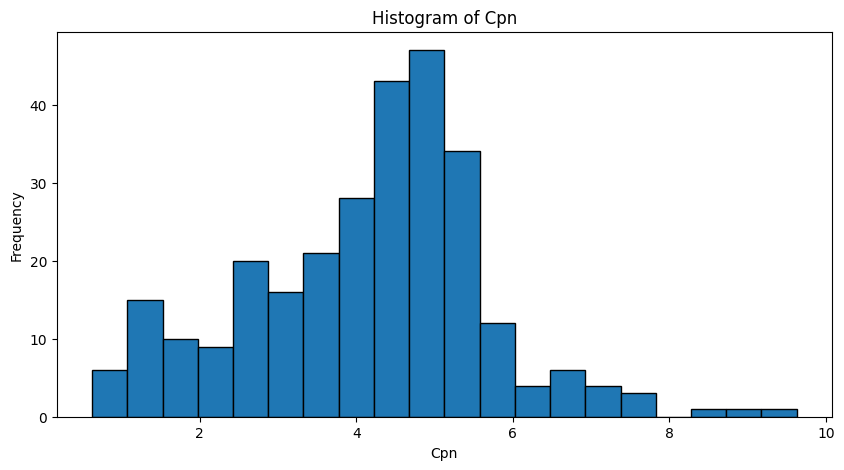

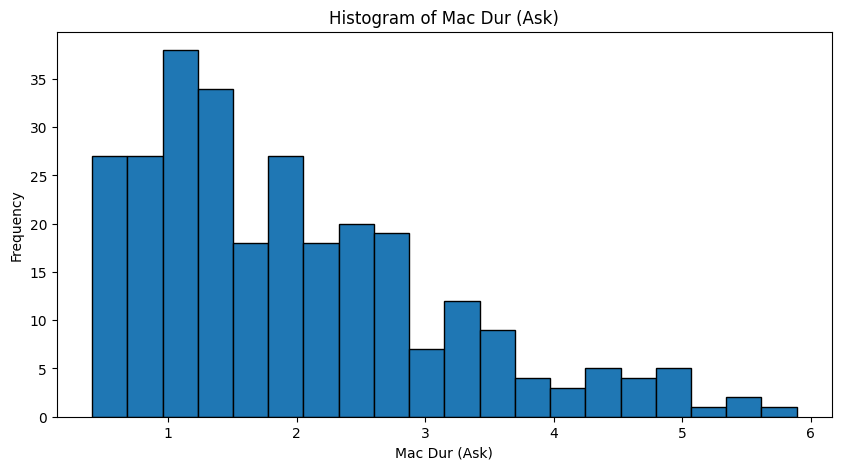

In [55]:
# Plot histograms of Bid Price and Ask Price
plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Bid Price'], bins=20, edgecolor='black')
plt.title('Histogram of Bid Price')
plt.xlabel('Bid Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Ask Price'], bins=20, edgecolor='black')
plt.title('Histogram of Ask Price')
plt.xlabel('Ask Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Amt Out'], bins=20, edgecolor='black')
plt.title('Histogram of Amt Out')
plt.xlabel('Amt Out')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Cpn'], bins=20, edgecolor='black')
plt.title('Histogram of Cpn')
plt.xlabel('Cpn')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Mac Dur (Ask)'], bins=20, edgecolor='black')
plt.title('Histogram of Mac Dur (Ask)')
plt.xlabel('Mac Dur (Ask)')
plt.ylabel('Frequency')
plt.show()

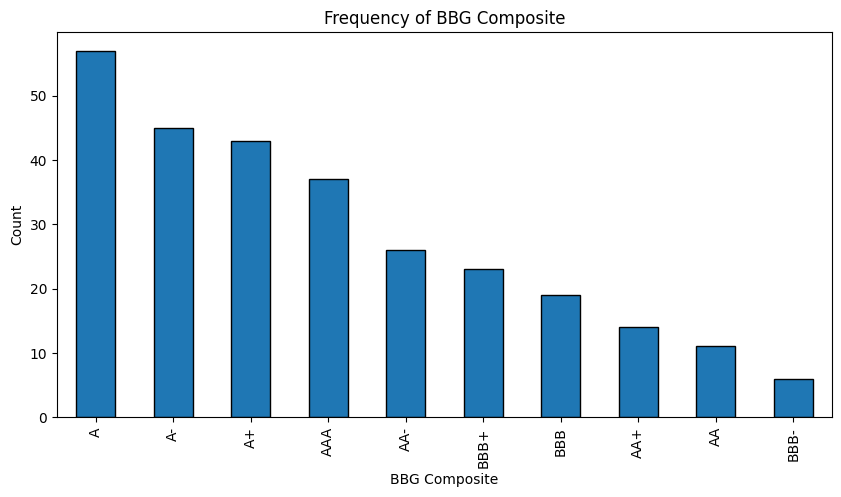

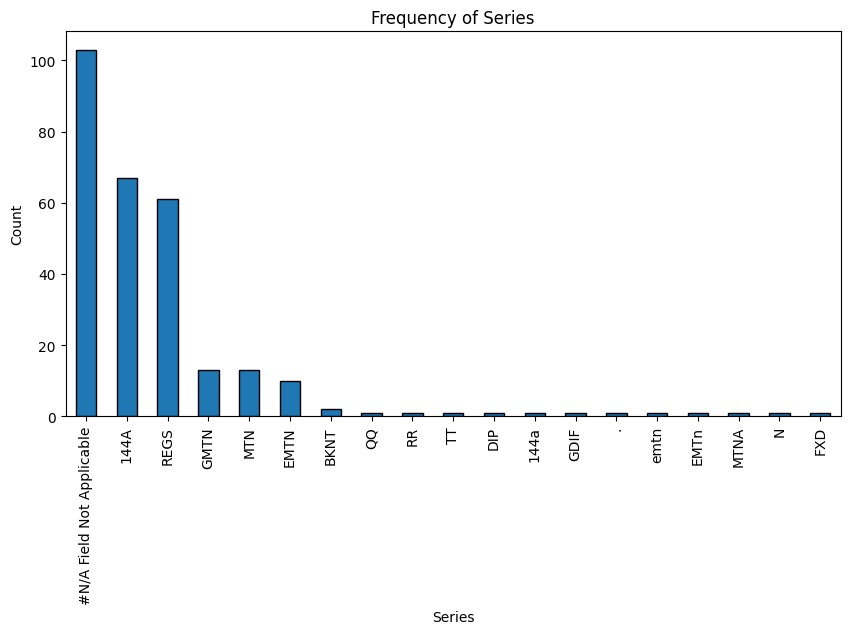

In [56]:
plt.figure(figsize=(10, 5))
bonds_df['BBG Composite'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of BBG Composite')
plt.xlabel('BBG Composite')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
bonds_df['Series'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of Series')
plt.xlabel('Series')
plt.ylabel('Count')
plt.show()

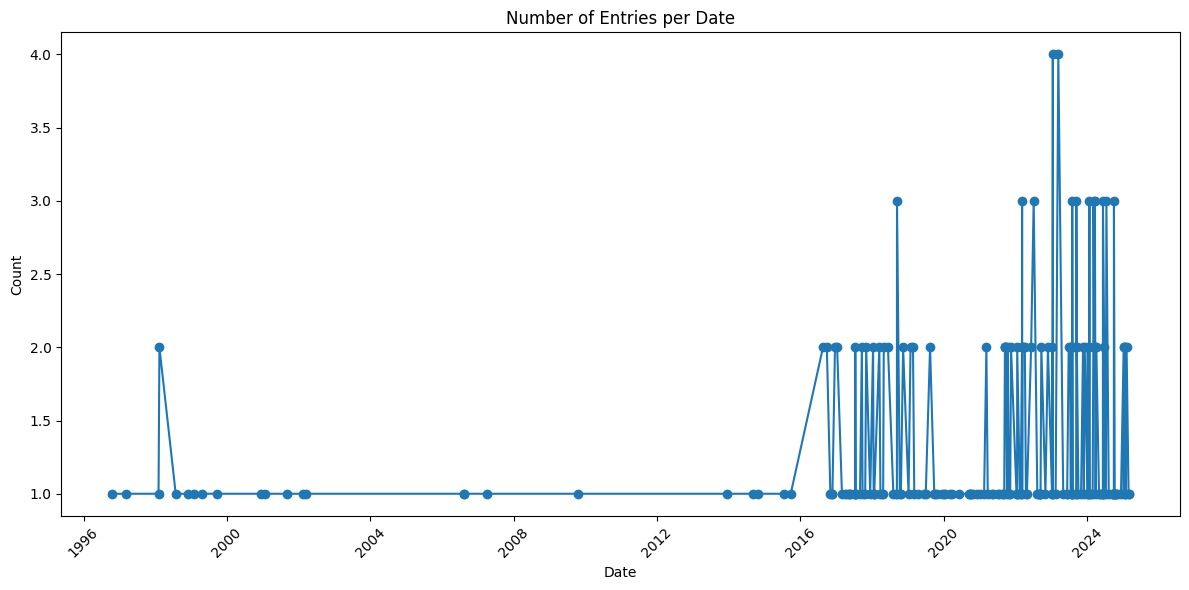

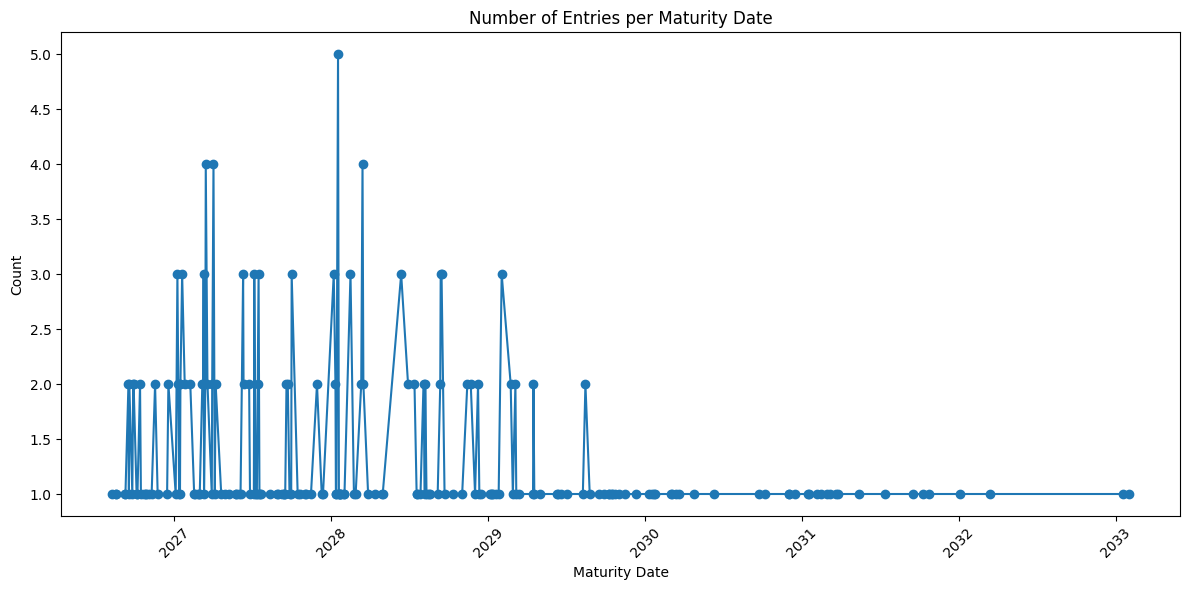

In [57]:
# Convert the 'Date' column to datetime if it's not already
bonds_df['Issue Date'] = pd.to_datetime(bonds_df['Issue Date'])

# Group by date and count the number of entries per date
date_counts = bonds_df['Issue Date'].value_counts().sort_index()

# Plot line from min to max date with count on y axis
plt.figure(figsize=(12, 6))
plt.plot(date_counts.index, date_counts.values, marker='o', linestyle='-')
plt.title('Number of Entries per Date')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Convert the 'Date' column to datetime if it's not already
bonds_df['Maturity'] = pd.to_datetime(bonds_df['Maturity'])

# Group by date and count the number of entries per date
date_counts = bonds_df['Maturity'].value_counts().sort_index()

# Plot line from min to max date with count on y axis
plt.figure(figsize=(12, 6))
plt.plot(date_counts.index, date_counts.values, marker='o', linestyle='-')
plt.title('Number of Entries per Maturity Date')
plt.xlabel('Maturity Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

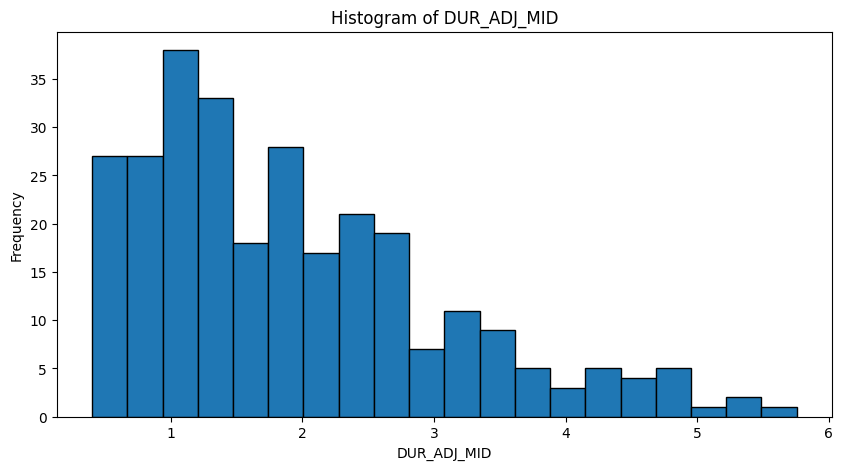

In [58]:
plt.figure(figsize=(10, 5))
plt.hist(bonds_df['DUR_ADJ_MID'], bins=20, edgecolor='black')
plt.title('Histogram of DUR_ADJ_MID')
plt.xlabel('DUR_ADJ_MID')
plt.ylabel('Frequency')
plt.show()

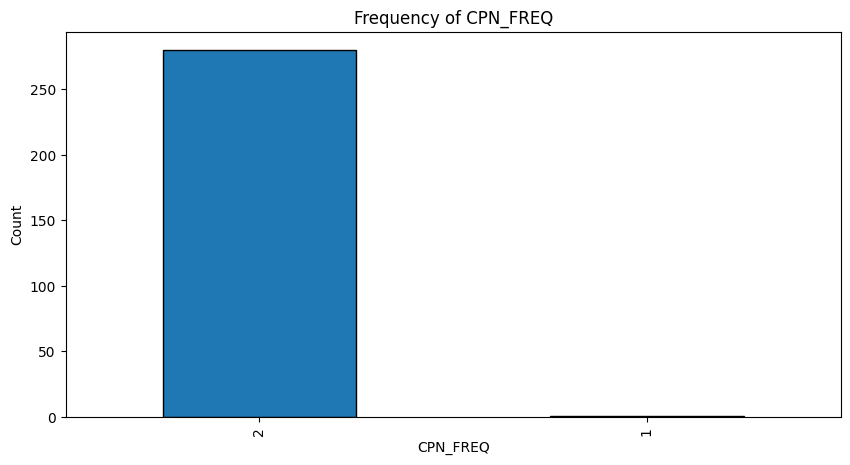

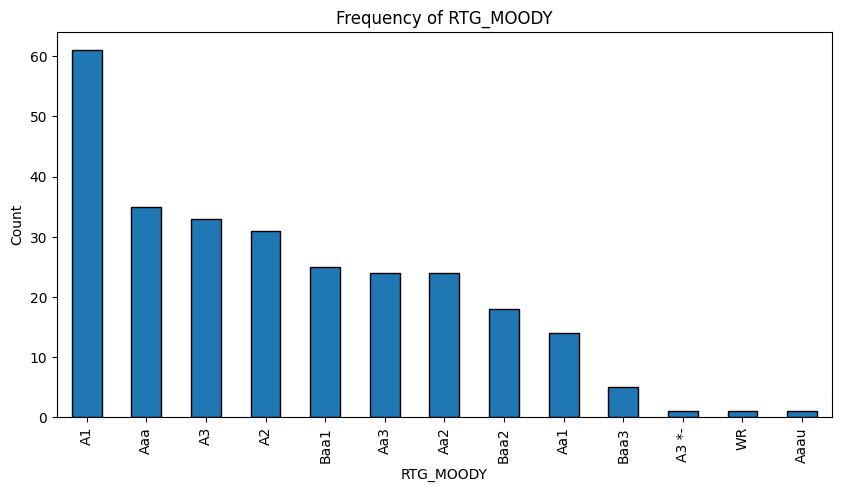

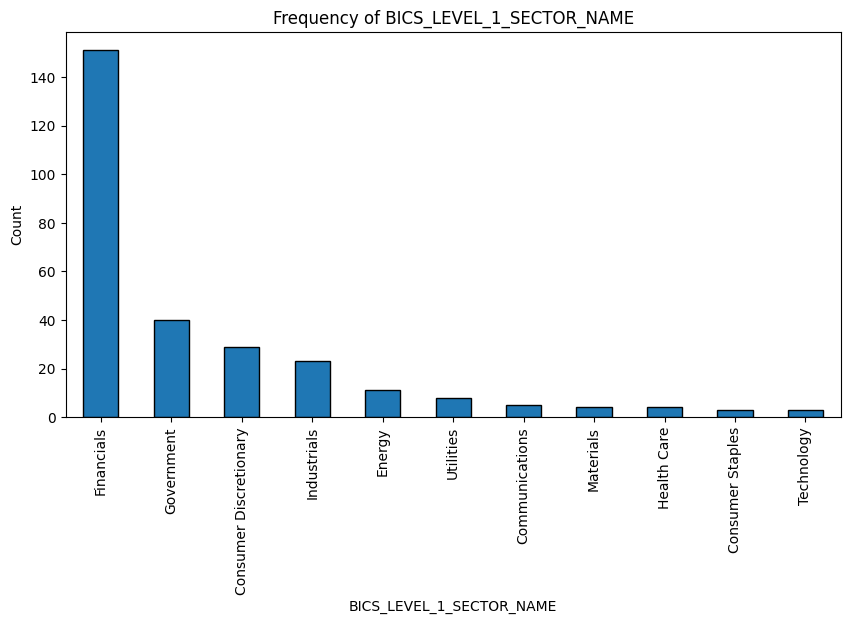

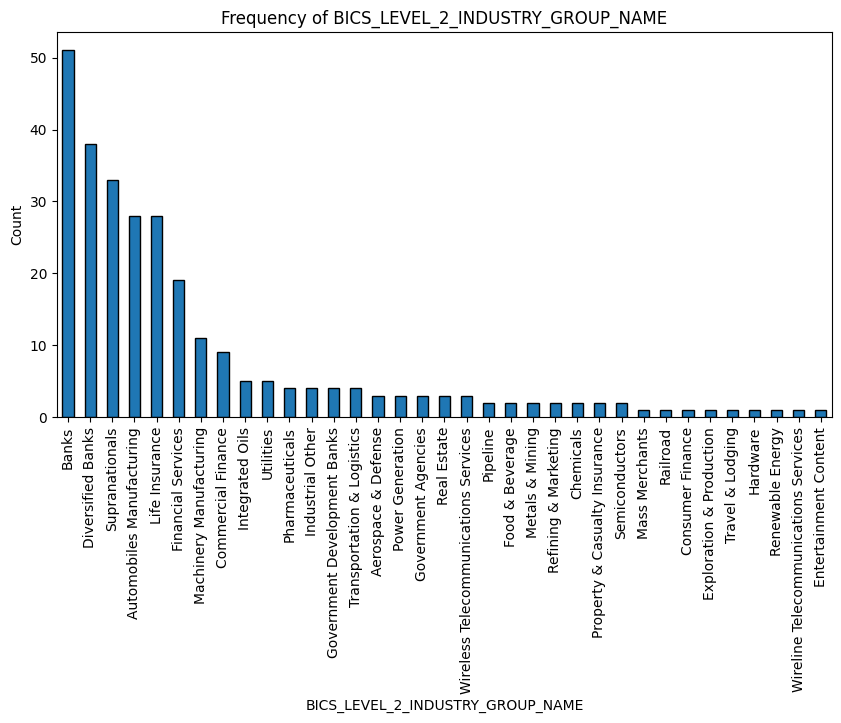

In [59]:
plt.figure(figsize=(10, 5))
bonds_df['CPN_FREQ'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of CPN_FREQ')
plt.xlabel('CPN_FREQ')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
bonds_df['RTG_MOODY'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of RTG_MOODY')
plt.xlabel('RTG_MOODY')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
bonds_df['BICS_LEVEL_1_SECTOR_NAME'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of BICS_LEVEL_1_SECTOR_NAME')
plt.xlabel('BICS_LEVEL_1_SECTOR_NAME')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
bonds_df['BICS_LEVEL_2_INDUSTRY_GROUP_NAME'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of BICS_LEVEL_2_INDUSTRY_GROUP_NAME')
plt.xlabel('BICS_LEVEL_2_INDUSTRY_GROUP_NAME')
plt.ylabel('Count')
plt.show()

## Price Sheet

In [60]:
price_df.head()

,Unnamed: 0,ZJ7425375,02665WFE6,BS2091905,04010LBE2,04685A3C3,05964HAF2,05964HAJ4,05964HAM7,06051GFL8,...,91311QAC9,92343VER1,92344GAM8,AV5564795,928668AU6,931142CH4,254687FQ4,94974BGL8,961214EL3,961214FT5
0,2024-03-01,101.455,100.021,92.080,102.404,86.358,94.579,96.650,85.747,98.197,...,106.536,97.531,114.902,99.057,99.057,104.463,94.953,97.579,89.160,100.023
1,2024-03-04,101.434,99.897,91.931,102.292,86.277,94.572,96.541,85.676,98.011,...,106.404,97.485,114.857,99.001,99.001,104.415,94.714,97.408,88.818,99.888
2,2024-03-05,101.651,99.444,92.053,102.355,86.417,94.699,96.626,85.833,98.033,...,106.471,97.688,114.897,99.005,99.005,104.385,95.065,97.538,89.092,99.818
3,2024-03-06,101.343,99.345,92.063,102.328,86.260,94.802,96.849,86.224,98.052,...,106.718,97.880,115.175,99.202,99.202,104.505,95.323,97.541,89.321,99.956
4,2024-03-07,101.572,99.250,92.219,102.579,86.355,95.075,97.050,86.377,98.192,...,106.878,98.026,115.496,99.383,99.383,104.699,95.512,97.815,89.645,100.425


In [61]:
# Remove columns whose last (non-null) value is not at the last row index (latest date)
last_date = price_df.index[-2]
cols_to_keep = [col for col in price_df.columns if price_df[col].last_valid_index() == last_date]
price_df = price_df[cols_to_keep]

Price DF shape: (504, 187)
Price DF columns: Index(['Unnamed: 0', 'ZJ7425375', 'BS2091905', '04010LBE2', '04685A3C3',
       '05964HAF2', '05964HAJ4', '05964HAM7', '06051GFL8', 'AN2054384',
       ...
       '907818CF3', '91311QAC9', '92343VER1', '92344GAM8', 'AV5564795',
       '928668AU6', '931142CH4', '254687FQ4', '94974BGL8', '961214EL3'],
      dtype='object', length=187)
Missing values per column:
Unnamed: 0    1
ZJ7425375     1
BS2091905     1
04010LBE2     1
04685A3C3     1
             ..
928668AU6     1
931142CH4     1
254687FQ4     1
94974BGL8     1
961214EL3     1
Length: 187, dtype: int64


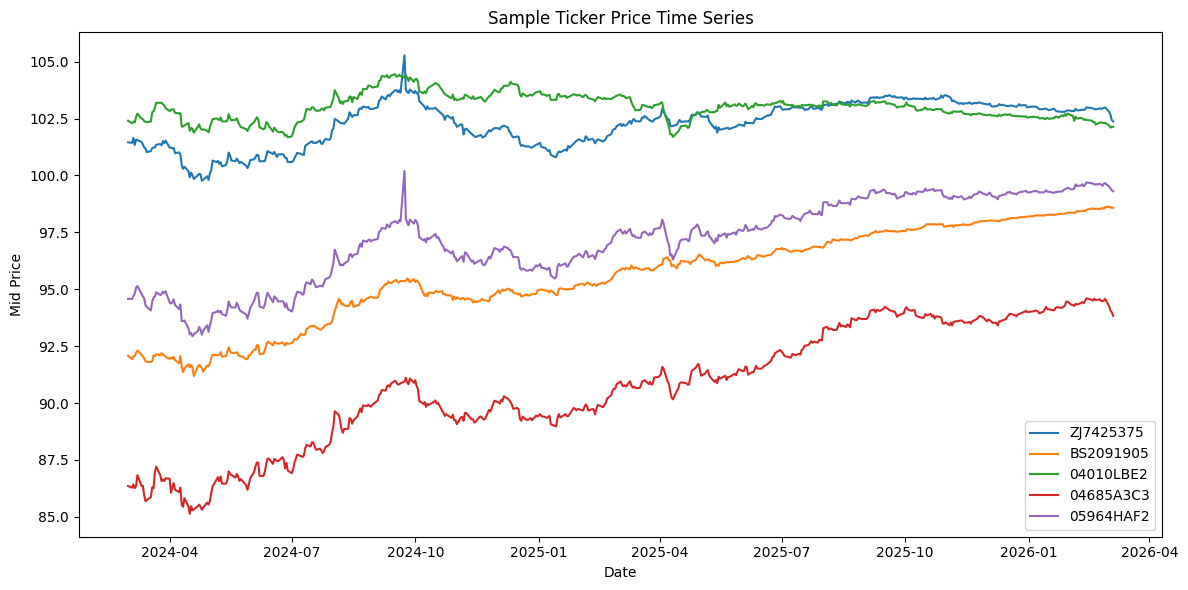

Summary statistics for tickers:
                 mean       std      min      max
ZJ7425375  102.281330  0.970426   99.768  105.282
BS2091905   95.521970  2.062597   91.187   98.627
04010LBE2  102.995038  0.575037  101.680  104.450
04685A3C3   90.705082  2.641034   85.133   94.602
05964HAF2   97.152787  1.805261   92.930  100.203
...               ...       ...      ...      ...
928668AU6   99.247435  1.330301   96.643  101.360
931142CH4  103.652101  0.627034  102.406  105.552
254687FQ4   97.118513  1.802210   92.755   99.964
94974BGL8   99.278288  1.115206   96.263  100.606
961214EL3   92.129002  2.229023   87.295   95.800

[186 rows x 4 columns]


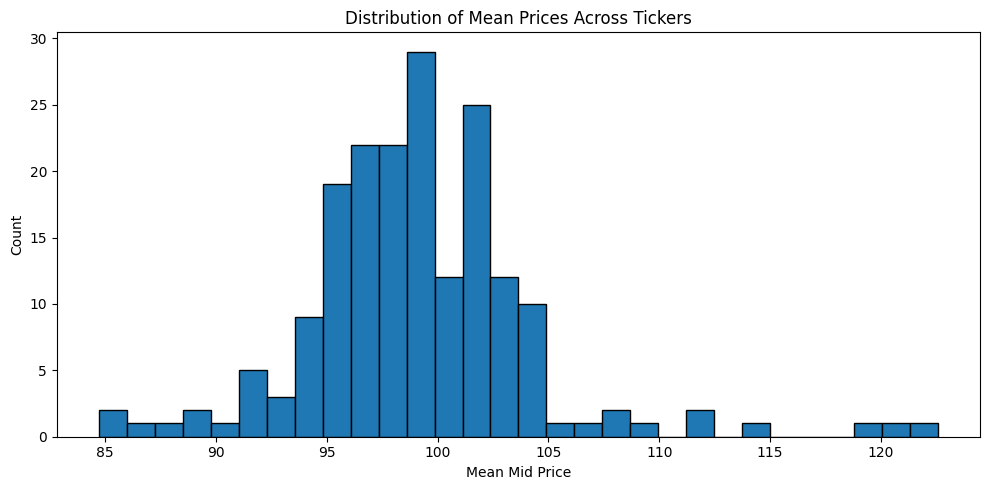

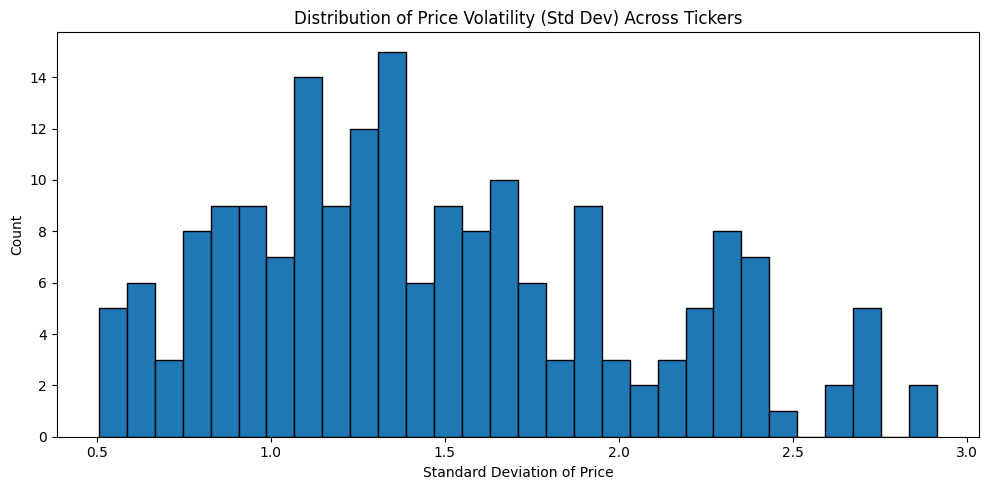

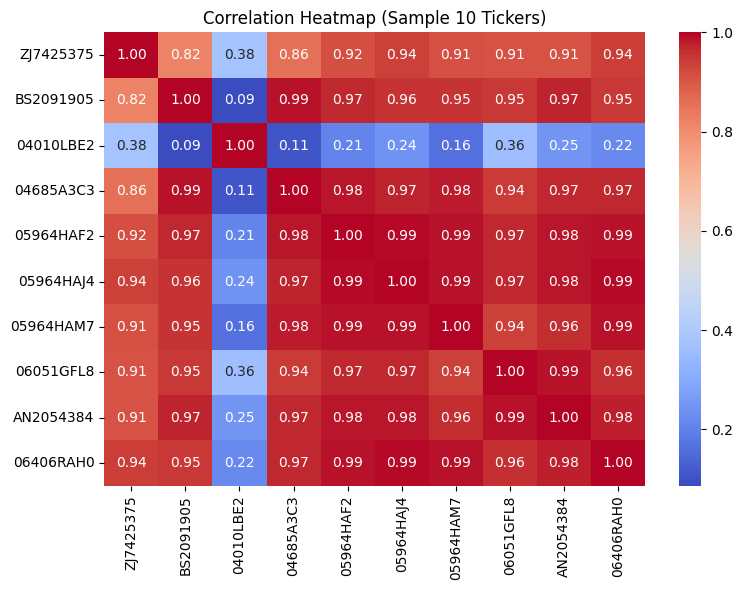

Top 10 tickers with most missing values:
ZJ7425375    0.001984
74256MET0    0.001984
686330AQ4    0.001984
686330AJ0    0.001984
69371RS64    0.001984
717081EA7    0.001984
69349LAS7    0.001984
ZM1977697    0.001984
73730EAD5    0.001984
74256LES4    0.001984
dtype: float64


In [62]:
# 1. Check general info and missing values
print("Price DF shape:", price_df.shape)
print("Price DF columns:", price_df.columns)
print("Missing values per column:")
print(price_df.isnull().sum())

# 2. Convert the date column to datetime and set as index if not already
price_df = price_df.copy()
if not pd.api.types.is_datetime64_any_dtype(price_df.iloc[:,0]):
    price_df.iloc[:,0] = pd.to_datetime(price_df.iloc[:,0])
price_df = price_df.set_index(price_df.columns[0])

# 3. Plot timeseries for a few tickers to visualize price evolution
sample_tickers = price_df.columns[:5]  # pick first 5, or random/sample as you prefer
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    plt.plot(price_df.index, price_df[ticker], label=ticker)
plt.legend()
plt.title('Sample Ticker Price Time Series')
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.tight_layout()
plt.show()

# 4. Plot summary statistics
summary = price_df.describe().T[['mean', 'std', 'min', 'max']]
print("Summary statistics for tickers:")
print(summary)

# 5. Plot distribution of means across all tickers
plt.figure(figsize=(10, 5))
plt.hist(price_df.mean(), bins=30, edgecolor='black')
plt.title('Distribution of Mean Prices Across Tickers')
plt.xlabel('Mean Mid Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Plot distribution of volatility (standard deviation) across all tickers
plt.figure(figsize=(10, 5))
plt.hist(price_df.std(), bins=30, edgecolor='black')
plt.title('Distribution of Price Volatility (Std Dev) Across Tickers')
plt.xlabel('Standard Deviation of Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Correlation heatmap among tickers - only for a subset due to high number
subset = price_df.columns[:10]
corr = price_df[subset].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Sample 10 Tickers)')
plt.tight_layout()
plt.show()

# 8. Identify tickers with most missing data
missing_pct = price_df.isnull().mean().sort_values(ascending=False)
print("Top 10 tickers with most missing values:")
print(missing_pct.head(10))

## Bid Sheet

In [63]:
bid_df = bid_df[cols_to_keep]

In [64]:
bid_df.head()

,Unnamed: 0,ZJ7425375,BS2091905,04010LBE2,04685A3C3,05964HAF2,05964HAJ4,05964HAM7,06051GFL8,AN2054384,...,907818CF3,91311QAC9,92343VER1,92344GAM8,AV5564795,928668AU6,931142CH4,254687FQ4,94974BGL8,961214EL3
0,2024-03-01,101.285,92.051,102.295,86.230,94.502,96.546,85.673,98.094,96.543,...,108.465,106.379,97.481,114.782,99.003,99.003,104.348,94.874,97.499,88.958
1,2024-03-04,101.307,91.897,102.156,86.150,94.505,96.416,85.551,97.950,96.270,...,108.369,106.323,97.389,114.730,98.926,98.926,104.305,94.657,97.273,88.682
2,2024-03-05,101.532,91.971,102.235,86.273,94.616,96.574,85.754,97.934,96.378,...,108.633,106.272,97.635,114.802,98.963,98.963,104.307,95.008,97.442,88.972
3,2024-03-06,101.188,92.046,102.245,86.158,94.719,96.763,86.159,97.986,96.379,...,108.777,106.561,97.842,115.046,99.118,99.118,104.372,95.277,97.463,89.203
4,2024-03-07,101.398,92.140,102.371,86.270,94.990,96.960,86.271,98.103,96.539,...,108.998,106.802,97.976,115.356,99.334,99.334,104.585,95.357,97.661,89.549


Bid DF shape: (504, 187)
Bid DF columns: Index(['Unnamed: 0', 'ZJ7425375', 'BS2091905', '04010LBE2', '04685A3C3',
       '05964HAF2', '05964HAJ4', '05964HAM7', '06051GFL8', 'AN2054384',
       ...
       '907818CF3', '91311QAC9', '92343VER1', '92344GAM8', 'AV5564795',
       '928668AU6', '931142CH4', '254687FQ4', '94974BGL8', '961214EL3'],
      dtype='object', length=187)
Missing values per column:
Unnamed: 0    1
ZJ7425375     1
BS2091905     1
04010LBE2     1
04685A3C3     1
             ..
928668AU6     1
931142CH4     1
254687FQ4     1
94974BGL8     1
961214EL3     1
Length: 187, dtype: int64


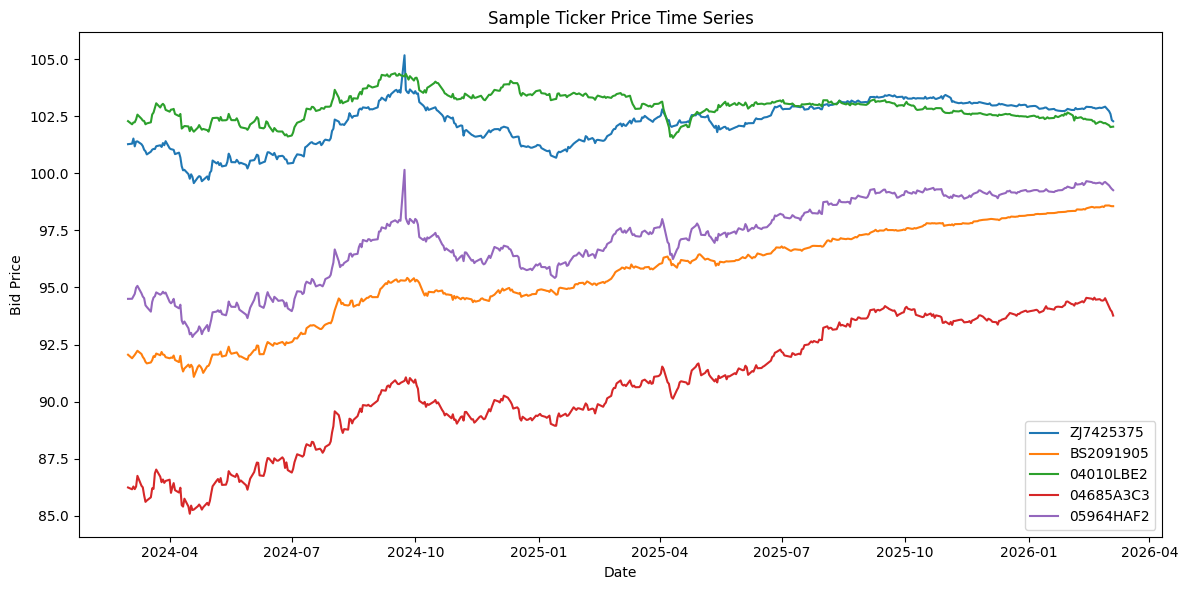

Summary statistics for tickers:
                 mean       std      min      max
ZJ7425375  102.178954  0.990638   99.577  105.184
BS2091905   95.477437  2.078275   91.081   98.597
04010LBE2  102.928167  0.588133  101.562  104.394
04685A3C3   90.652058  2.649100   85.076   94.554
05964HAF2   97.102559  1.812843   92.831  100.160
...               ...       ...      ...      ...
928668AU6   99.191805  1.338975   96.520  101.311
931142CH4  103.571489  0.629004  102.344  105.511
254687FQ4   97.077843  1.807125   92.705   99.935
94974BGL8   99.226915  1.127578   96.163  100.574
961214EL3   92.079706  2.243126   87.243   95.766

[186 rows x 4 columns]


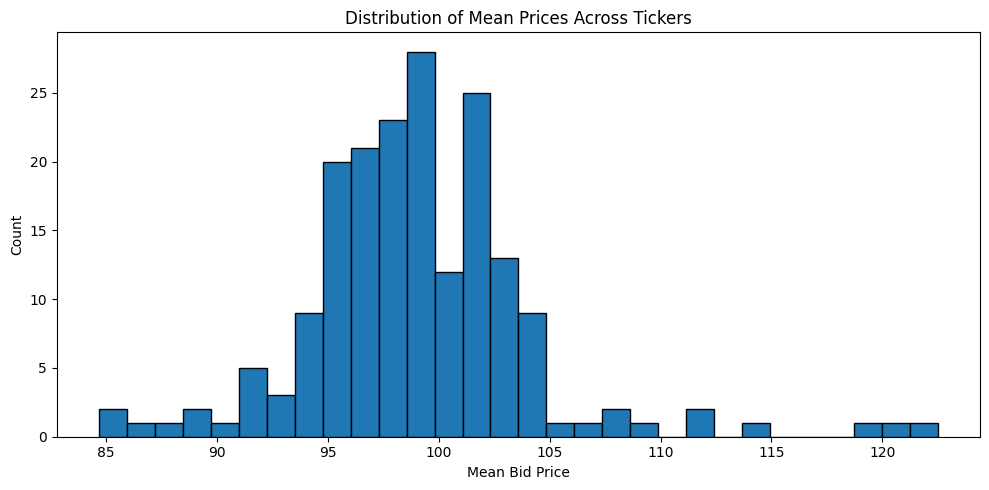

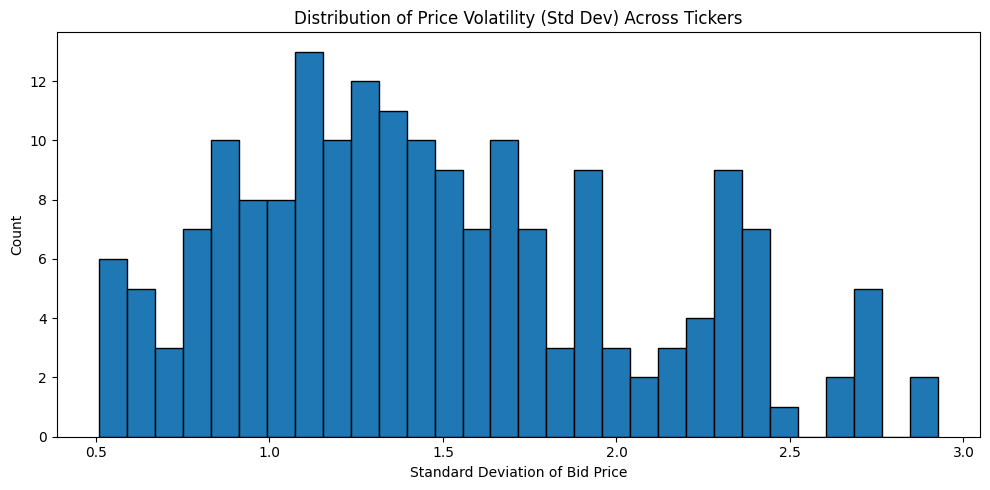

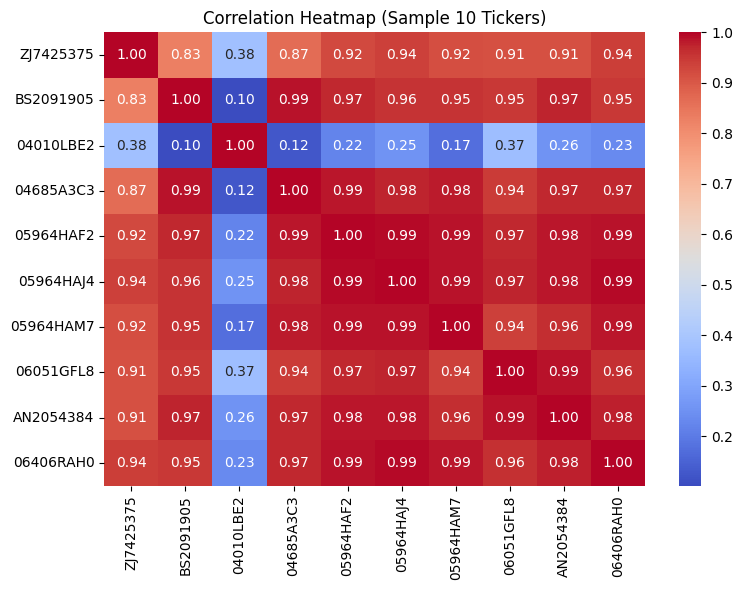

Top 10 tickers with most missing values:
ZJ7425375    0.001984
66815M2Q9    0.001984
686330AQ4    0.001984
686330AJ0    0.001984
69371RS64    0.001984
717081EA7    0.001984
69349LAS7    0.001984
73730EAD5    0.001984
74256LES4    0.001984
74256LEW5    0.001984
dtype: float64


In [65]:
# 1. Check general info and missing values
print("Bid DF shape:", bid_df.shape)
print("Bid DF columns:", bid_df.columns)
print("Missing values per column:")
print(bid_df.isnull().sum())

# 2. Convert the date column to datetime and set as index if not already
bid_df = bid_df.copy()
if not pd.api.types.is_datetime64_any_dtype(bid_df.iloc[:,0]):
    bid_df.iloc[:,0] = pd.to_datetime(bid_df.iloc[:,0])
bid_df = bid_df.set_index(bid_df.columns[0])

# 3. Plot timeseries for a few tickers to visualize price evolution
sample_tickers = bid_df.columns[:5]  # pick first 5, or random/sample as you prefer
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    plt.plot(bid_df.index, bid_df[ticker], label=ticker)
plt.legend()
plt.title('Sample Ticker Price Time Series')
plt.xlabel('Date')
plt.ylabel('Bid Price')
plt.tight_layout()
plt.show()

# 4. Plot summary statistics
summary = bid_df.describe().T[['mean', 'std', 'min', 'max']]
print("Summary statistics for tickers:")
print(summary)

# 5. Plot distribution of means across all tickers
plt.figure(figsize=(10, 5))
plt.hist(bid_df.mean(), bins=30, edgecolor='black')
plt.title('Distribution of Mean Prices Across Tickers')
plt.xlabel('Mean Bid Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Plot distribution of volatility (standard deviation) across all tickers
plt.figure(figsize=(10, 5))
plt.hist(bid_df.std(), bins=30, edgecolor='black')
plt.title('Distribution of Price Volatility (Std Dev) Across Tickers')
plt.xlabel('Standard Deviation of Bid Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Correlation heatmap among tickers - only for a subset due to high number
subset = bid_df.columns[:10]
corr = bid_df[subset].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Sample 10 Tickers)')
plt.tight_layout()
plt.show()

# 8. Identify tickers with most missing data
missing_pct = bid_df.isnull().mean().sort_values(ascending=False)
print("Top 10 tickers with most missing values:")
print(missing_pct.head(10))

## Ask Sheet

In [66]:
ask_df = ask_df[cols_to_keep]

In [67]:
ask_df.head()

,Unnamed: 0,ZJ7425375,BS2091905,04010LBE2,04685A3C3,05964HAF2,05964HAJ4,05964HAM7,06051GFL8,AN2054384,...,907818CF3,91311QAC9,92343VER1,92344GAM8,AV5564795,928668AU6,931142CH4,254687FQ4,94974BGL8,961214EL3
0,2024-03-01,101.625,92.109,102.513,86.486,94.656,96.754,85.821,98.300,96.623,...,108.631,106.693,97.581,115.022,99.111,99.111,104.578,95.032,97.659,89.362
1,2024-03-04,101.561,91.965,102.428,86.404,94.639,96.666,85.801,98.072,96.390,...,108.581,106.485,97.581,114.984,99.076,99.076,104.525,94.771,97.543,88.954
2,2024-03-05,101.770,92.135,102.475,86.561,94.782,96.678,85.912,98.132,96.512,...,108.851,106.670,97.741,114.992,99.047,99.047,104.463,95.122,97.634,89.212
3,2024-03-06,101.498,92.080,102.411,86.362,94.885,96.935,86.289,98.118,96.519,...,109.001,106.875,97.918,115.304,99.286,99.286,104.638,95.369,97.619,89.439
4,2024-03-07,101.746,92.298,102.787,86.440,95.160,97.140,86.483,98.281,96.661,...,109.170,106.954,98.076,115.636,99.432,99.432,104.813,95.667,97.969,89.741


Ask DF shape: (503, 187)
Ask DF columns: Index(['Unnamed: 0', 'ZJ7425375', 'BS2091905', '04010LBE2', '04685A3C3',
       '05964HAF2', '05964HAJ4', '05964HAM7', '06051GFL8', 'AN2054384',
       ...
       '907818CF3', '91311QAC9', '92343VER1', '92344GAM8', 'AV5564795',
       '928668AU6', '931142CH4', '254687FQ4', '94974BGL8', '961214EL3'],
      dtype='object', length=187)
Missing values per column:
Unnamed: 0    0
ZJ7425375     0
BS2091905     0
04010LBE2     0
04685A3C3     0
             ..
928668AU6     0
931142CH4     0
254687FQ4     0
94974BGL8     0
961214EL3     0
Length: 187, dtype: int64


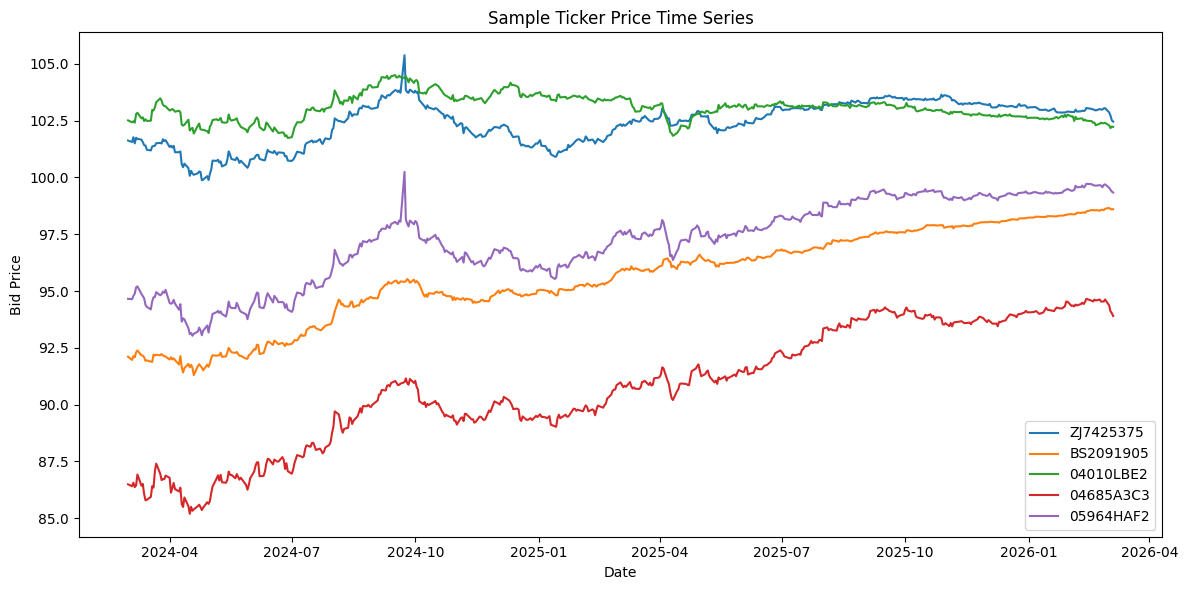

Summary statistics for tickers:
                 mean       std      min      max
ZJ7425375  102.383706  0.951187   99.875  105.380
BS2091905   95.566503  2.047037   91.293   98.657
04010LBE2  103.061909  0.563514  101.738  104.506
04685A3C3   90.758105  2.633123   85.190   94.658
05964HAF2   97.203016  1.797874   93.029  100.246
...               ...       ...      ...      ...
928668AU6   99.303066  1.321892   96.686  101.409
931142CH4  103.732714  0.627320  102.468  105.602
254687FQ4   97.159183  1.797424   92.805   99.993
94974BGL8   99.329662  1.103177   96.363  100.638
961214EL3   92.178298  2.215138   87.347   95.834

[186 rows x 4 columns]


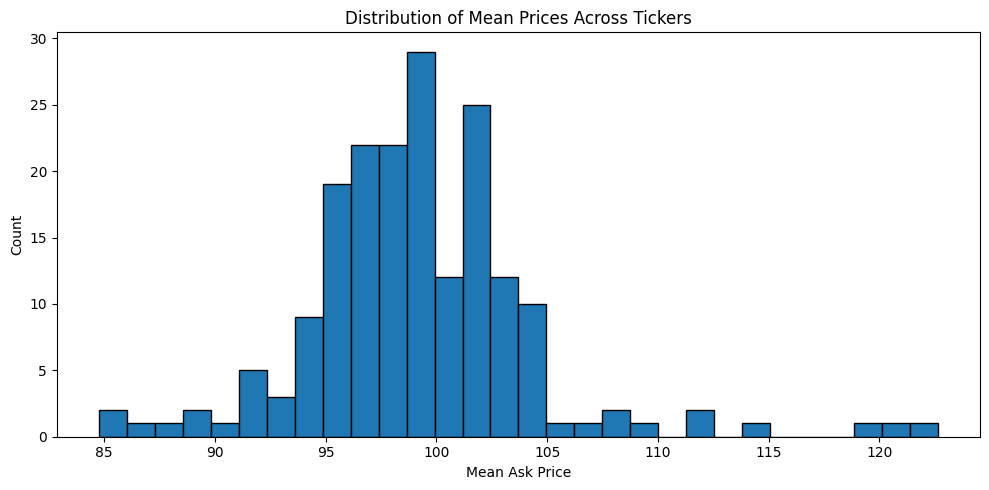

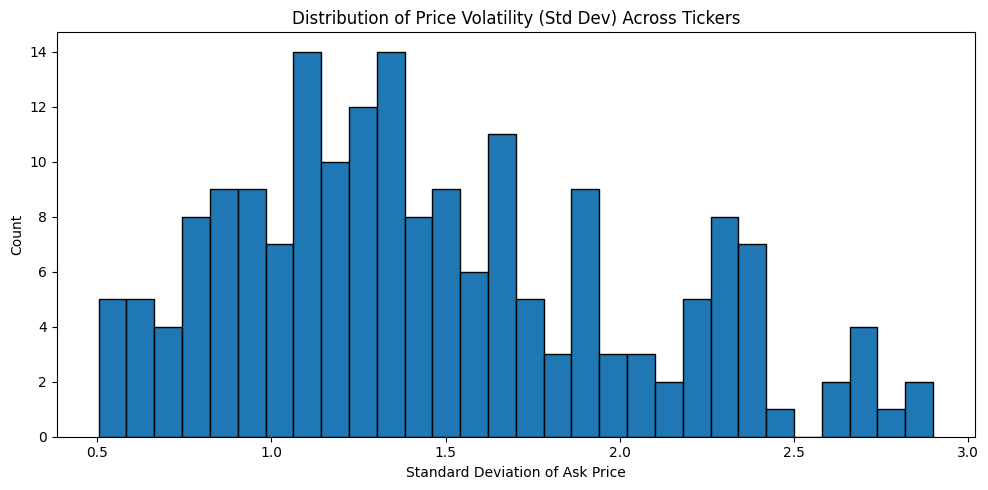

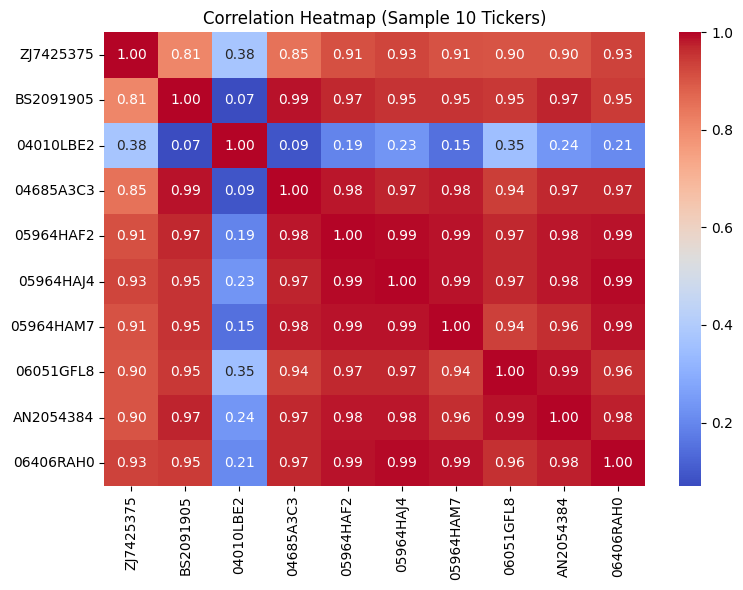

Top 10 tickers with most missing values:
ZJ7425375    0.0
74256MET0    0.0
686330AQ4    0.0
686330AJ0    0.0
69371RS64    0.0
717081EA7    0.0
69349LAS7    0.0
ZM1977697    0.0
73730EAD5    0.0
74256LES4    0.0
dtype: float64


In [68]:
# 1. Check general info and missing values
print("Ask DF shape:", ask_df.shape)
print("Ask DF columns:", ask_df.columns)
print("Missing values per column:")
print(ask_df.isnull().sum())

# 2. Convert the date column to datetime and set as index if not already
ask_df = ask_df.copy()
if not pd.api.types.is_datetime64_any_dtype(ask_df.iloc[:,0]):
    ask_df.iloc[:,0] = pd.to_datetime(ask_df.iloc[:,0])
ask_df = ask_df.set_index(ask_df.columns[0])

# 3. Plot timeseries for a few tickers to visualize price evolution
sample_tickers = ask_df.columns[:5]  # pick first 5, or random/sample as you prefer
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    plt.plot(ask_df.index, ask_df[ticker], label=ticker)
plt.legend()
plt.title('Sample Ticker Price Time Series')
plt.xlabel('Date')
plt.ylabel('Bid Price')
plt.tight_layout()
plt.show()

# 4. Plot summary statistics
summary = ask_df.describe().T[['mean', 'std', 'min', 'max']]
print("Summary statistics for tickers:")
print(summary)

# 5. Plot distribution of means across all tickers
plt.figure(figsize=(10, 5))
plt.hist(ask_df.mean(), bins=30, edgecolor='black')
plt.title('Distribution of Mean Prices Across Tickers')
plt.xlabel('Mean Ask Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Plot distribution of volatility (standard deviation) across all tickers
plt.figure(figsize=(10, 5))
plt.hist(ask_df.std(), bins=30, edgecolor='black')
plt.title('Distribution of Price Volatility (Std Dev) Across Tickers')
plt.xlabel('Standard Deviation of Ask Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Correlation heatmap among tickers - only for a subset due to high number
subset = ask_df.columns[:10]
corr = ask_df[subset].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Sample 10 Tickers)')
plt.tight_layout()
plt.show()

# 8. Identify tickers with most missing data
missing_pct = ask_df.isnull().mean().sort_values(ascending=False)
print("Top 10 tickers with most missing values:")
print(missing_pct.head(10))